In [1]:
from pyrokinetics import Pyro, PyroScan
import os
from pathlib import Path
import numpy as np

In [2]:
# Replace with path to your Gyrokinetic Simulations
GYRO_DIR  = Path("/mnt/data/Gyrokinetic_Simulations/")

In [3]:
cases = ["M1_A1","S1"]
projects = ["nl_exb_scan"]

In [4]:
project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        json_path = Path(GYRO_DIR / Path(f"GENE/Runs/{project}/{case}/pyroscan.json"))
        net_cdf_path = Path(GYRO_DIR / Path(f"GENE/Runs/{project}/{case}/pyroscan.nc"))
        gene_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
        gene_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
        case_dict[case] = gene_pyoscan
        project_dict[project] = case_dict

/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0000'. 
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/pyro.py:1785: UserWarning: Explicitly set value of beta (0.09 beta_ref_ee_B0_pyroscan_base0001) is inconsistent with value from physical reference values (0.09617910133883377 beta_ref_ee_B0_pyroscan_base0001)
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0001'. 
  warnings.warn(


In [25]:
tglf_versions = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules = ["sat1","sat2","sat3"]
tglf_grid_models = [1,4]

name_dict = {
    "tglf_default":"Default",
    "tglf_default_negwm":"Default_EMWS",
    "tglf_v1": "V1",
    "tglf_v1_negwm": "V1_EMWS",
    "tglf_v2": "V2",
}

tglf_project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        version_dict = {}
        for version in tglf_versions:
            sat_rules = {}
            for sat_rule in tglf_sat_rules:
                grid_models = {}
                for grid_model in tglf_grid_models:
                    json_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/{version}/{sat_rule}_kygrid{grid_model}/pyroscan.json"))
                    net_cdf_path = Path(GYRO_DIR / Path(f"TGLF/Runs/{project}/{case}/{version}/{sat_rule}_kygrid{grid_model}/pyroscan.nc"))
                    try:
                        tglf_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
                        tglf_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                        grid_models[grid_model] = tglf_pyoscan
                    except Exception as e:
                        print(f"Error loading pyroscan for {project}/{case}/{version}/{sat_rule}_kygrid{grid_model}: {e}")
                sat_rules[sat_rule] = grid_models
            version_dict[version] = sat_rules
        case_dict[case] = version_dict
    tglf_project_dict[project] = case_dict

Error loading pyroscan for nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid1: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid1/pyroscan.json'
Error loading pyroscan for nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid4: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_default_negwm/sat1_kygrid4/pyroscan.json'
Error loading pyroscan for nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid1: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid1/pyroscan.json'
Error loading pyroscan for nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid4: [Errno 2] No such file or directory: '/mnt/data/Gyrokinetic_Simulations/TGLF/Runs/nl_exb_scan/M1_A1/tglf_v1_negwm/sat1_kygrid4/pyroscan.json'
Error loading pyroscan for nl_exb_scan/S1/tglf_default_negwm/sat1_kygrid1: [Errno 2] No such file or directory: '/mnt/da

Error plotting tglf_default sat1 grid model 1: 1
Error plotting tglf_default sat1 grid model 4: 4
Error plotting tglf_default sat2 grid model 1: 1
Error plotting tglf_default sat2 grid model 4: 4
Error plotting tglf_default sat3 grid model 1: 1
Error plotting tglf_default sat3 grid model 4: 4
Error plotting tglf_default_negwm sat1 grid model 1: 1
Error plotting tglf_default_negwm sat1 grid model 4: 4
Error plotting tglf_default_negwm sat2 grid model 1: 1
Error plotting tglf_default_negwm sat2 grid model 4: 4
Error plotting tglf_default_negwm sat3 grid model 1: 1
Error plotting tglf_default_negwm sat3 grid model 4: 4
Error plotting tglf_v1 sat1 grid model 1: 1
Error plotting tglf_v1 sat1 grid model 4: 4
Error plotting tglf_v1 sat2 grid model 1: 1
Error plotting tglf_v1 sat2 grid model 4: 4
Error plotting tglf_v1 sat3 grid model 1: 1
Error plotting tglf_v1 sat3 grid model 4: 4
Error plotting tglf_v1_negwm sat1 grid model 1: 1
Error plotting tglf_v1_negwm sat1 grid model 4: 4
Error plotti

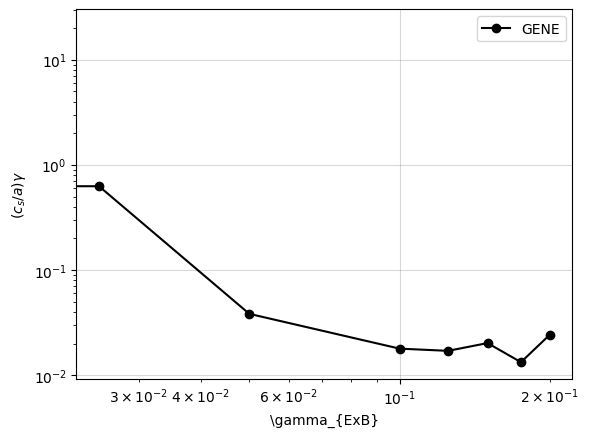

In [6]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "S1"
reference_exb = 3.49


for tglf in tglf_versions:
    for sat_rule in tglf_sat_rules:
        for grid_model in tglf_grid_models:
            try:
                (tglf_project_dict[project][case][tglf][sat_rule][grid_model]
                    .gk_output["heat"].sum(dim="species").sum(dim="field")
                    .plot(label=tglf, marker="o", linestyle="--"))
            except Exception as e:
                print(f"Error plotting {tglf} {sat_rule} grid model {grid_model}: {e}")



project_dict[project][case].gk_output["heat"].sum(dim="species").sum(dim="field").plot(label="GENE", color="black", marker="o")



#plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title("")
plt.xlabel(r"\gamma_{ExB}")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
plt.legend()
plt.yscale("log")
plt.xscale("log")
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
#plt.savefig(f"{path}/Growth Rate vs q — {case}, ky={ky_actual:.3f}.png", dpi=300)



/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


Plotting tglf_default sat3 grid model 4
Error plotting tglf_default sat3 grid model 4: 4
Plotting tglf_default_negwm sat3 grid model 4
Error plotting tglf_default_negwm sat3 grid model 4: 4
Plotting tglf_v1 sat3 grid model 4
Error plotting tglf_v1 sat3 grid model 4: 4
Plotting tglf_v1_negwm sat3 grid model 4
Error plotting tglf_v1_negwm sat3 grid model 4: 4
Plotting tglf_v2 sat3 grid model 4
Error plotting tglf_v2 sat3 grid model 4: 4


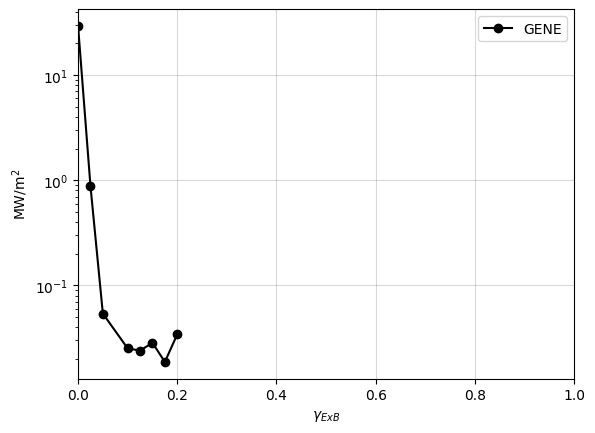

In [7]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "S1"
reference_exb = 3.49

tglf_versions_to_plot = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules_to_plot = ["sat3"]
tglf_grid_models_to_plot = [4]


GENE_context = project_dict[project][case].base_pyro.norms.context

GENE_Heat = project_dict[project][case].gk_output["heat"].sum(dim="species").sum(dim="field").data.to("MW/m^2",GENE_context)
GENE_exb = project_dict[project][case].gk_output["heat"]["gamma_exb"]
plt.plot(GENE_exb,np.abs(GENE_Heat), label="GENE", color="black", marker="o")

for tglf in tglf_versions_to_plot:
    for sat_rule in tglf_sat_rules_to_plot:
        for grid_model in tglf_grid_models_to_plot:
            print(f"Plotting {tglf} {sat_rule} grid model {grid_model}")
            try:
                tglf_heat = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["heat"].sum(dim="species").sum(dim="field").data.to("MW/m^2",GENE_context)
                tglf_exb = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["heat"]["gamma_exb"]
                plt.plot(tglf_exb, np.abs(tglf_heat), label=f"{tglf}_{sat_rule}_kx_{grid_model}", marker="o", linestyle="--")
            except Exception as e:
                print(f"Error plotting {tglf} {sat_rule} grid model {grid_model}: {e}")




#plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title("")
plt.ylabel(r"MW/m$^2$")
plt.xlabel(r"$\gamma_{ExB}$")
plt.grid(alpha=0.3, color='grey')
plt.legend()
plt.yscale("log")
#plt.xscale("log")
plt.xlim(GENE_exb[0],5*GENE_exb[-1])
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Heat Flux - ExB shear — {case}.png", dpi=300)



In [ ]:
# from matplotlib import pyplot as plt
# # Plot Q scan
# project = "nl_exb_scan"
# case = "M1_A1"
# reference_exb = 3.49

# tglf_versions_to_plot = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
# tglf_sat_rules_to_plot = ["sat2"]
# tglf_grid_models_to_plot = [4]


# for tglf in tglf_versions_to_plot:
#     for sat_rule in tglf_sat_rules_to_plot:
#         for grid_model in tglf_grid_models_to_plot:
#             tglf_heat = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["growth_rate"].isel(gamma_exb=10).isel(mode=0).plot(label=f"{tglf}_{sat_rule}_kx_{grid_model}")

# plt.legend()
# plt.xscale("log")

KeyError: 4

In [9]:
cases = ["M1_A1_NE","S1"]
projects = ["scan_ky_default"]
gs2_project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        print(f"Project: {project}, Case: {case}")
        json_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.json"))
        net_cdf_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.nc"))
        try:
            gs2_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
            try:
                gs2_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                case_dict[case] = gs2_pyoscan
            except Exception as e:
                print(f"Error loading gk output for {project}/{case}: {e}")
                try:
                    gs2_pyoscan.load_gk_output()
                    gs2_pyoscan.gk_output.to_netcdf(net_cdf_path)
                    case_dict[case] = gs2_pyoscan
                except Exception as e:
                    print(f"Error loading gk output without netcdf for {project}/{case}: {e}")
        except Exception as e:
            print(f"Error loading pyroscan for {project}/{case}: {e}")
            continue
    gs2_project_dict[project] = case_dict

Project: scan_ky_default, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0054'. 
  warnings.warn(


Project: scan_ky_default, Case: S1


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/pyro.py:1785: UserWarning: Explicitly set value of beta (0.01 beta_ref_ee_B0_pyroscan_base0055) is inconsistent with value from physical reference values (0.09617910133883378 beta_ref_ee_B0_pyroscan_base0055)
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0055'. 
  warnings.warn(


In [10]:
cases = ["M1_A1_NE"]
projects = ["scan_beta"]
gs2_project_dict ={}
for project in projects:
    case_dict = {}
    for case in cases:
        print(f"Project: {project}, Case: {case}")
        json_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.json"))
        net_cdf_path = Path(GYRO_DIR / Path(f"GS2/Runs/{project}/{case}/parameter_scan_GS2/pyroscan.nc"))
        try:
            gs2_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
            try:
                gs2_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
                case_dict[case] = gs2_pyoscan
            except Exception as e:
                print(f"Error loading gk output for {project}/{case}: {e}")
                try:
                    gs2_pyoscan.load_gk_output()
                    gs2_pyoscan.gk_output.to_netcdf(net_cdf_path)
                    case_dict[case] = gs2_pyoscan
                except Exception as e:
                    print(f"Error loading gk output without netcdf for {project}/{case}: {e}")
        except Exception as e:
            print(f"Error loading pyroscan for {project}/{case}: {e}")
            continue
    gs2_project_dict[project] = case_dict

Project: scan_beta, Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0056'. 
  warnings.warn(


In [11]:
gs2_project_dict["scan_ky_default"]["M1_A1_NE"].gk_output["growth_rate"].plot(label="GS2", color="black")


KeyError: 'scan_ky_default'

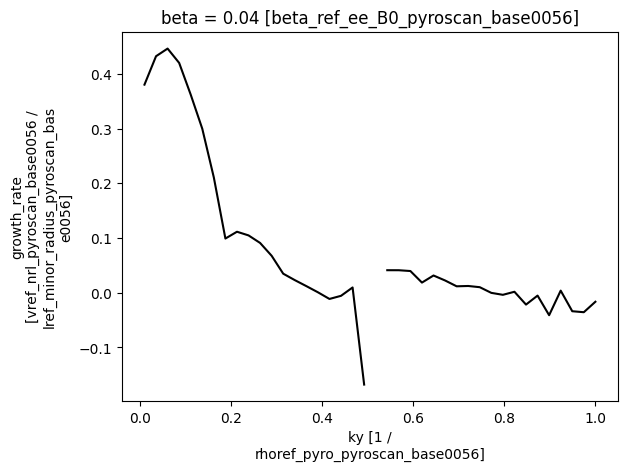

In [12]:
gs2_project_dict["scan_beta"]["M1_A1_NE"].gk_output["growth_rate"].sel(beta = 0.04,method="nearest").plot(label="GS2", color="black")

In [13]:
gs2_project_dict["scan_ky_default"]["M1_A1_NE"].base_pyro.numerics["beta"]

KeyError: 'scan_ky_default'

In [14]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "M1_A1"
reference_beta = 0.036

tglf_versions_to_plot = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules_to_plot = ["sat2"]
tglf_grid_models_to_plot = [4]


for tglf in tglf_versions_to_plot:
    for sat_rule in tglf_sat_rules_to_plot:
        for grid_model in tglf_grid_models_to_plot:
            tglf_heat = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["growth_rate"].isel(gamma_exb=10).isel(mode=0).plot(label=f"{tglf}_{sat_rule}_kx_{grid_model}")

gs2_project_dict["scan_ky_default"]["M1_A1_NE"].gk_output["growth_rate"].plot(label="GS2", color="black")

plt.legend()
plt.xscale("log")
plt.yscale("log")

KeyError: 4

In [15]:
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "M1_A1"
reference_beta = 0.036

tglf_versions_to_plot = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules_to_plot = ["sat2"]
tglf_grid_models_to_plot = [4]


for tglf in tglf_versions_to_plot:
    for sat_rule in tglf_sat_rules_to_plot:
        for grid_model in tglf_grid_models_to_plot:
            tglf_heat = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["growth_rate"].isel(gamma_exb=10).isel(mode=0).plot(label=f"{tglf}_{sat_rule}_kx_{grid_model}")

gs2_project_dict["scan_ky_default"]["M1_A1_NE"].gk_output["growth_rate"].plot(label="GS2", color="black")

plt.legend()
plt.xlim(0.01,1)
plt.xscale("log")
plt.yscale("log")

KeyError: 4

In [16]:
cases = ["M1_A1","S1"]
projects = ["nl_exb_scan"]

project_dict_full ={}
for project in projects:
    case_dict = {}
    for case in cases:
        json_path = Path(GYRO_DIR / Path(f"GENE/Runs/{project}/{case}/pyroscan.json"))
        net_cdf_path = Path(GYRO_DIR / Path(f"GENE/Runs/{project}/{case}/pyroscan_full.nc"))
        gene_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
        gene_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
        case_dict[case] = gene_pyoscan
    project_dict_full[project] = case_dict

/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0057'. 
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/pyro.py:1785: UserWarning: Explicitly set value of beta (0.09 beta_ref_ee_B0_pyroscan_base0058) is inconsistent with value from physical reference values (0.09617910133883377 beta_ref_ee_B0_pyroscan_base0058)
  warnings.warn(
/home/Felix/Documents/Physics_Work/Project_Codes/EPS_2026_Analysis/.venv/lib/python3.14/site-packages/pyrokinetics/normalisation.py:941: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0058'. 
  warnings.warn(


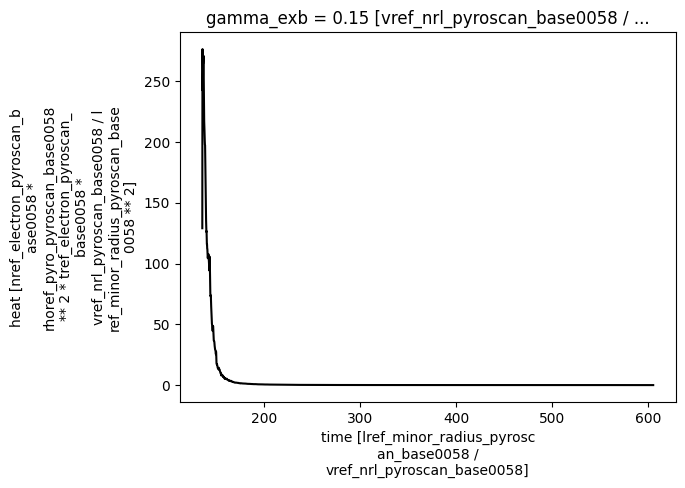

In [17]:
project_dict_full["nl_exb_scan"]["S1"].gk_output["heat"].sum(dim="species").sum(dim="field").isel(gamma_exb = 5).plot(label="GENE", color="black")

In [19]:
def converged_flux(da, t_frac=0.2, time_dim="time", n_blocks=None):
    """
    Converged value + 1-sigma uncertainty of a saturated turbulence time trace.

    da       : 1D xarray.DataArray of Q(t) (already reduced to a single time series)
    t_start  : time after which the trace is saturated (discard transient before this)
    n_blocks : number of blocks for block-averaging. If None, chosen as ~T/(5*tau_c).
    """
    da = da.where((da != 0) & da.notnull(), drop=True)
    time = da[time_dim]
    t_start = time.max().item() - t_frac * (time.max().item() - time.min().item())
    q = da.where(da[time_dim] >= t_start, drop=True)
    t = q[time_dim].values
    y = np.asarray(q.values, dtype=float)
    N = y.size
    mean = y.mean()

    # --- integrated autocorrelation time (in samples) ---
    yc = y - mean
    acf = np.correlate(yc, yc, mode="full")[N - 1:]
    acf /= acf[0]
    first_neg = np.argmax(acf < 0)            # integrate up to first zero crossing
    cutoff = first_neg if first_neg > 0 else N
    tau_int = 1.0 + 2.0 * acf[1:cutoff].sum()  # in samples
    dt = np.median(np.diff(t))
    tau_c = tau_int * dt                       # correlation time in time units
    N_eff = N / max(tau_int, 1.0)

    # --- block (batch-means) standard error ---
    if n_blocks is None:
        n_blocks = max(4, int(N / (5 * max(tau_int, 1.0))))  # >= 5 tau per block
    n_blocks = min(n_blocks, N)
    edges = np.array_split(np.arange(N), n_blocks)
    block_means = np.array([y[idx].mean() for idx in edges])
    sem = block_means.std(ddof=1) / np.sqrt(len(block_means))

    return {
        "mean": mean,
        "sem": sem,            # 1-sigma uncertainty on the mean
        "tau_c": tau_c,        # correlation time (same units as t)
        "N_eff": N_eff,        # effective independent samples
        "n_blocks": len(block_means),
        "rel_err_%": 100 * sem / abs(mean),
    }

Plotting tglf_default sat3 grid model 4
Plotting tglf_default_negwm sat3 grid model 4
Plotting tglf_v1 sat3 grid model 4
Plotting tglf_v1_negwm sat3 grid model 4
Plotting tglf_v2 sat3 grid model 4


/tmp/ipykernel_36107/2691542251.py:25: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  np.asarray(trace.data.to("MW/m^2", GENE_context)),
/tmp/ipykernel_36107/2691542251.py:25: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  np.asarray(trace.data.to("MW/m^2", GENE_context)),
/tmp/ipykernel_36107/2691542251.py:25: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  np.asarray(trace.data.to("MW/m^2", GENE_context)),
/tmp/ipykernel_36107/2691542251.py:25: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  np.asarray(trace.data.to("MW/m^2", GENE_context)),
/tmp/ipykernel_36107/2691542251.py:25: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  np.asarray(trace.data.to("MW/m^2", GENE_context)),
/tmp/ipykernel_36107/2691542251.py:25: UnitStrippedWarning: The unit of the quantity is stripped when dow

AttributeError: 'ErrorbarContainer' object has no attribute 'get_color'

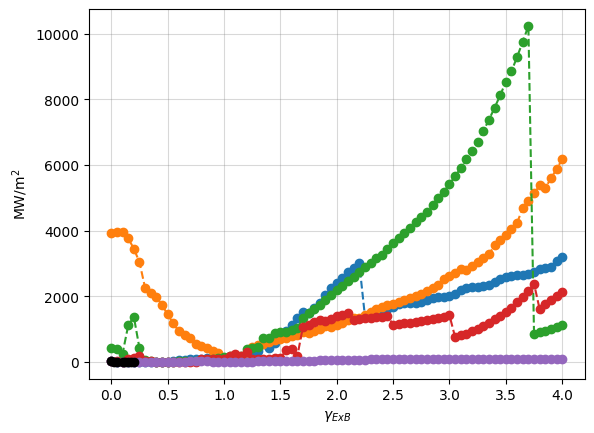

In [ ]:
import xarray as xr
from matplotlib import pyplot as plt
# Plot Q scan
project = "nl_exb_scan"
case = "S1"
reference_exb = 3.49
t_start_frac = 0.4   # discard this leading fraction of each GENE trace as transient



tglf_versions_to_plot = ["tglf_default","tglf_default_negwm","tglf_v1","tglf_v1_negwm","tglf_v2"]
tglf_sat_rules_to_plot = ["sat3"]
tglf_grid_models_to_plot = [4]

marker_map = {"sat1": "o", "sat2": "^", "sat3": "s"}

GENE_context = project_dict_full[project][case].base_pyro.norms.context

# --- GENE: converged value + uncertainty per gamma_exb (time-resolved data) ---
heat = project_dict_full[project][case].gk_output["heat"].sum(dim="species").sum(dim="field")
time_dim = "time" if "time" in heat.dims else [d for d in heat.dims if d != "gamma_exb"][0]

GENE_exb, GENE_mean, GENE_err = [], [], []
for i, g in enumerate(heat["gamma_exb"].values):
    trace = heat.isel(gamma_exb=i)
    trace_si = xr.DataArray(
        np.asarray(trace.data.to("MW/m^2", GENE_context)),
        coords={time_dim: trace[time_dim].values}, dims=[time_dim])
    t = trace_si[time_dim].values
    t0 = t[0] + t_start_frac * (t[-1] - t[0])
    res = converged_flux(trace_si, time_dim=time_dim)
    GENE_exb.append(float(g)); GENE_mean.append(res["mean"]); GENE_err.append(res["sem"])

GENE_exb = np.asarray(GENE_exb)
GENE_mean = np.asarray(GENE_mean)
GENE_err = np.asarray(GENE_err)

mask = GENE_mean > 0
plt.errorbar(GENE_exb[mask], GENE_mean[mask], yerr=GENE_err[mask],
             label="GENE", color="black", marker="o", capsize=3)

# --- TGLF (unchanged) ---
for tglf in tglf_versions_to_plot:
    for sat_rule in tglf_sat_rules_to_plot:
        for grid_model in tglf_grid_models_to_plot:
            print(f"Plotting {tglf} {sat_rule} grid model {grid_model}")
            try:
                tglf_heat = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["heat"].sum(dim="species").sum(dim="field").data.to("MW/m^2", GENE_context)
                tglf_exb = tglf_project_dict[project][case][tglf][sat_rule][grid_model].gk_output["heat"]["gamma_exb"]
                plt.plot(tglf_exb, tglf_heat,
                         label=f"{tglf}_{sat_rule}_kx_{grid_model}",
                         marker=marker_map.get(sat_rule, "o"),
                         linestyle="--")
            except Exception as e:
                print(f"Error plotting {tglf} {sat_rule} grid model {grid_model}: {e}")


#plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title("")
plt.ylabel(r"MW/m$^2$")
plt.xlabel(r"$\gamma_{ExB}$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()

def handle_color(handle):
    if hasattr(handle, "get_color"):
        return handle.get_color()
    if hasattr(handle, "lines") and len(handle.lines) > 0:
        return handle.lines[0].get_color()
    if isinstance(handle, (list, tuple)) and len(handle) > 0 and hasattr(handle[0], "get_color"):
        return handle[0].get_color()
    return "black"

def legend_marker(label):
    if "sat2" in label:
        return "^"
    if "sat3" in label:
        return "s"
    if "sat1" in label:
        return "o"
    return "o"

dot_handles = [
    Line2D([], [], color=handle_color(h),
           marker=legend_marker(lbl),
           linestyle="none", markersize=8)
    for h, lbl in zip(handles, labels)
]
plt.legend(dot_handles, labels)
plt.yscale("log")
plt.xscale("symlog", linthresh=0.01)
plt.xlim(GENE_exb[0], 20*GENE_exb[-1])
path = f"../Plots/{project}/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Heat Flux - ExB shear — {case}-with_errors.png", dpi=300)
#plt.savefig(f"{path}/Growth Rate vs q — {case}, ky={ky_actual:.3f}.png", dpi=300)


In [22]:
print(tglf_project_dict[project][case].keys())
print(tglf_project_dict[project][case]["tglf_default"].keys())
print(tglf_project_dict[project][case]["tglf_default"]["sat3"].keys())  # does "sat3" even exist?

dict_keys(['tglf_default', 'tglf_default_negwm', 'tglf_v1', 'tglf_v1_negwm', 'tglf_v2'])
dict_keys(['sat1', 'sat2', 'sat3'])
dict_keys(['Default'])


/tmp/ipykernel_816831/355312601.py:23: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  da = xr.DataArray(np.asarray(tr.data.to(to_units, ctx)),
/tmp/ipykernel_816831/355312601.py:23: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  da = xr.DataArray(np.asarray(tr.data.to(to_units, ctx)),
/tmp/ipykernel_816831/355312601.py:23: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  da = xr.DataArray(np.asarray(tr.data.to(to_units, ctx)),
/tmp/ipykernel_816831/355312601.py:23: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  da = xr.DataArray(np.asarray(tr.data.to(to_units, ctx)),
/tmp/ipykernel_816831/355312601.py:23: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  da = xr.DataArray(np.asarray(tr.data.to(to_units, ctx)),
/tmp/ipykernel_816831/355312601.py:23: UnitStrippedWarning: The unit of the

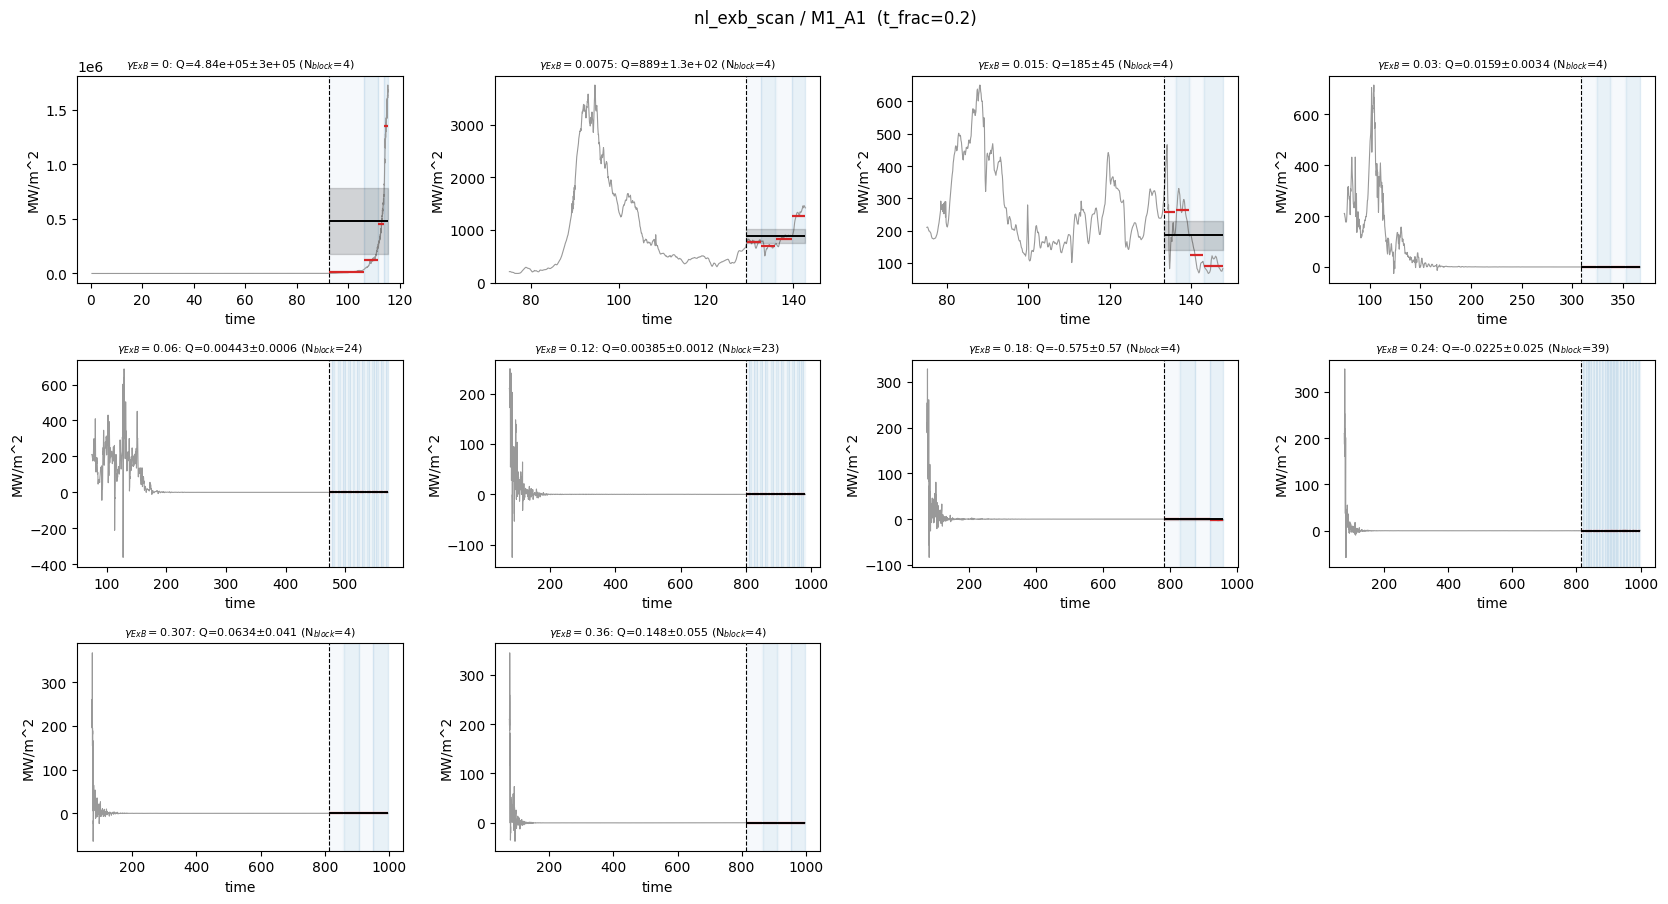

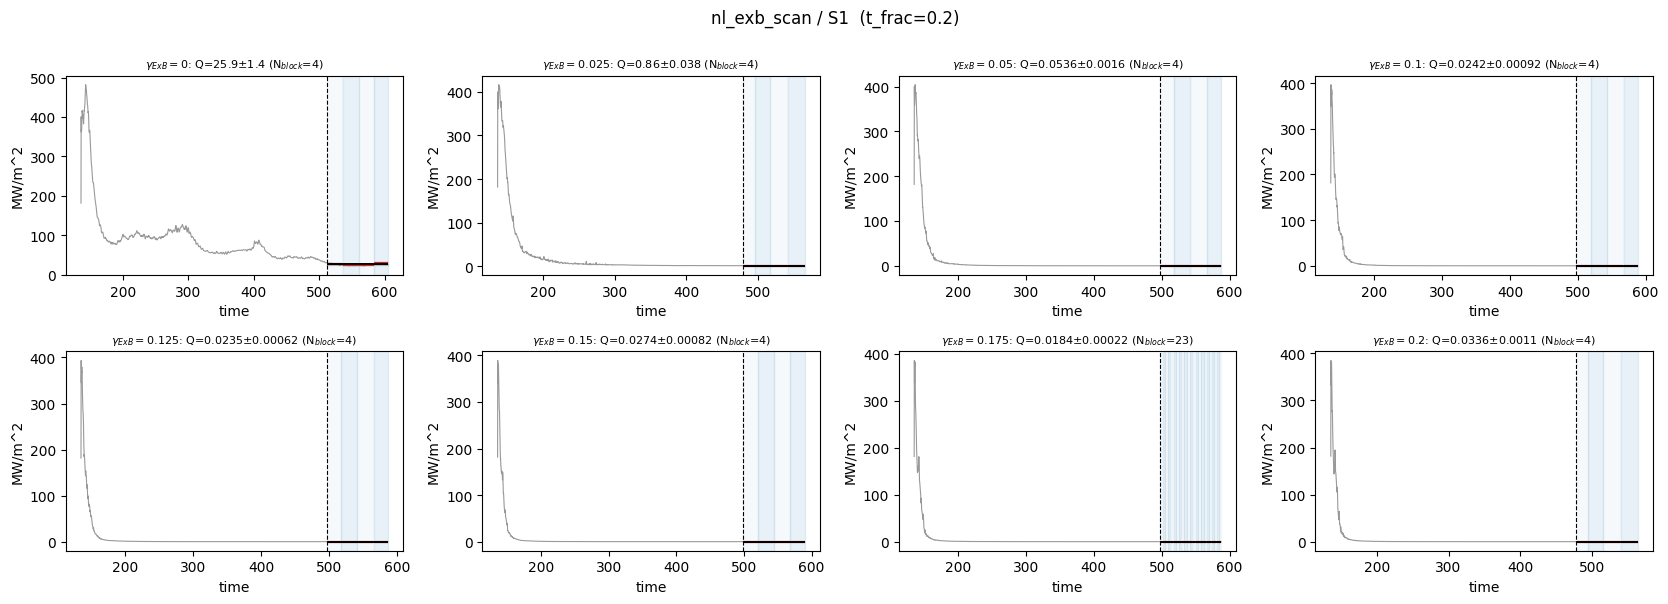

In [ ]:
import xarray as xr
from matplotlib import pyplot as plt

def plot_convergence(scan_dict, project, case, t_frac=0.2,
                     ncols=4, to_units="MW/m^2", n_blocks=None, zoom=False):

    """One panel per gamma_exb: time trace + averaging window + block boxes.
    Self-contained: replicates the converged_flux math so nothing can drift."""
    pyro = scan_dict[project][case]
    ctx = pyro.base_pyro.norms.context
    heat = pyro.gk_output["heat"].sum(dim="species").sum(dim="field")
    tdim = "time" if "time" in heat.dims else [d for d in heat.dims if d != "gamma_exb"][0]
    gammas = heat["gamma_exb"].values

    n = len(gammas)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3 * nrows),
                             squeeze=False)

    for k, (g, ax) in enumerate(zip(gammas, axes.flat)):
        tr = heat.isel(gamma_exb=k)
        da = xr.DataArray(np.asarray(tr.data.to(to_units, ctx)),
                          coords={tdim: tr[tdim].values}, dims=[tdim])
        da = da.where((da != 0) & da.notnull(), drop=True)     # strip padding

        # --- window ---
        time = da[tdim]
        t_start = time.max().item() - t_frac * (time.max().item() - time.min().item())
        q = da.where(da[tdim] >= t_start, drop=True)
        t = q[tdim].values
        y = np.asarray(q.values, dtype=float)
        N = y.size
        mean = y.mean()

        # --- autocorrelation time (for N_eff) ---
        yc = y - mean
        acf = np.correlate(yc, yc, mode="full")[N - 1:]
        acf /= acf[0]
        first_neg = np.argmax(acf < 0)
        cutoff = first_neg if first_neg > 0 else N
        tau_int = 1.0 + 2.0 * acf[1:cutoff].sum()
        N_eff = N / max(tau_int, 1.0)

        # --- blocks ---
        nb = n_blocks if n_blocks is not None else max(4, int(N / (5 * max(tau_int, 1.0))))
        nb = min(nb, N)
        edges = np.array_split(np.arange(N), nb)
        block_means = np.array([y[idx].mean() for idx in edges])
        sem = block_means.std(ddof=1) / np.sqrt(len(block_means))
        blocks = [(t[idx[0]], t[idx[-1]], y[idx].mean()) for idx in edges]

        # --- draw ---
        tt, yy = da[tdim].values, da.values
        ax.plot(tt, yy, color="0.6", lw=0.8)                   # full Q(t)
        for j, (tl, tr2, bm) in enumerate(blocks):             # block boxes
            ax.axvspan(tl, tr2, color="tab:blue", alpha=0.10 if j % 2 else 0.04)
            ax.hlines(bm, tl, tr2, color="tab:red", lw=1.6, zorder=5)
        t_end = tt[-1]
        ax.hlines(mean, t_start, t_end, color="k", lw=1.4, zorder=6)
        ax.fill_between([t_start, t_end], mean - sem, mean + sem,
                        color="k", alpha=0.15, zorder=4)
        ax.axvline(t_start, color="k", ls="--", lw=0.8)
        if zoom:
            ax.set_xlim(t_start, t_end)
            pad = 0.05 * (y.max() - y.min() or 1.0)
            ax.set_ylim(y.min() - pad, y.max() + pad)
        ax.set_title(r"$\gamma_{ExB}=%.3g$: Q=%.3g$\pm$%.2g (N$_{block}$=%.0f)"
                     % (g, mean, sem, nb), fontsize=8)
        ax.set_xlabel("time"); ax.set_ylabel(to_units)

    for ax in axes.flat[n:]:
        ax.axis("off")
    fig.suptitle(f"{project} / {case}  (t_frac={t_frac})", y=1.0)
    fig.tight_layout()
    return fig


project = "nl_exb_scan"
for case in project_dict_full[project]:
    plot_convergence(project_dict_full, project, case, t_frac=0.2)
plt.show()


/tmp/ipykernel_123756/355312601.py:23: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  da = xr.DataArray(np.asarray(tr.data.to(to_units, ctx)),
/tmp/ipykernel_123756/355312601.py:23: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  da = xr.DataArray(np.asarray(tr.data.to(to_units, ctx)),
/tmp/ipykernel_123756/355312601.py:23: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  da = xr.DataArray(np.asarray(tr.data.to(to_units, ctx)),
/tmp/ipykernel_123756/355312601.py:23: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  da = xr.DataArray(np.asarray(tr.data.to(to_units, ctx)),
/tmp/ipykernel_123756/355312601.py:23: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  da = xr.DataArray(np.asarray(tr.data.to(to_units, ctx)),
/tmp/ipykernel_123756/355312601.py:23: UnitStrippedWarning: The unit of the

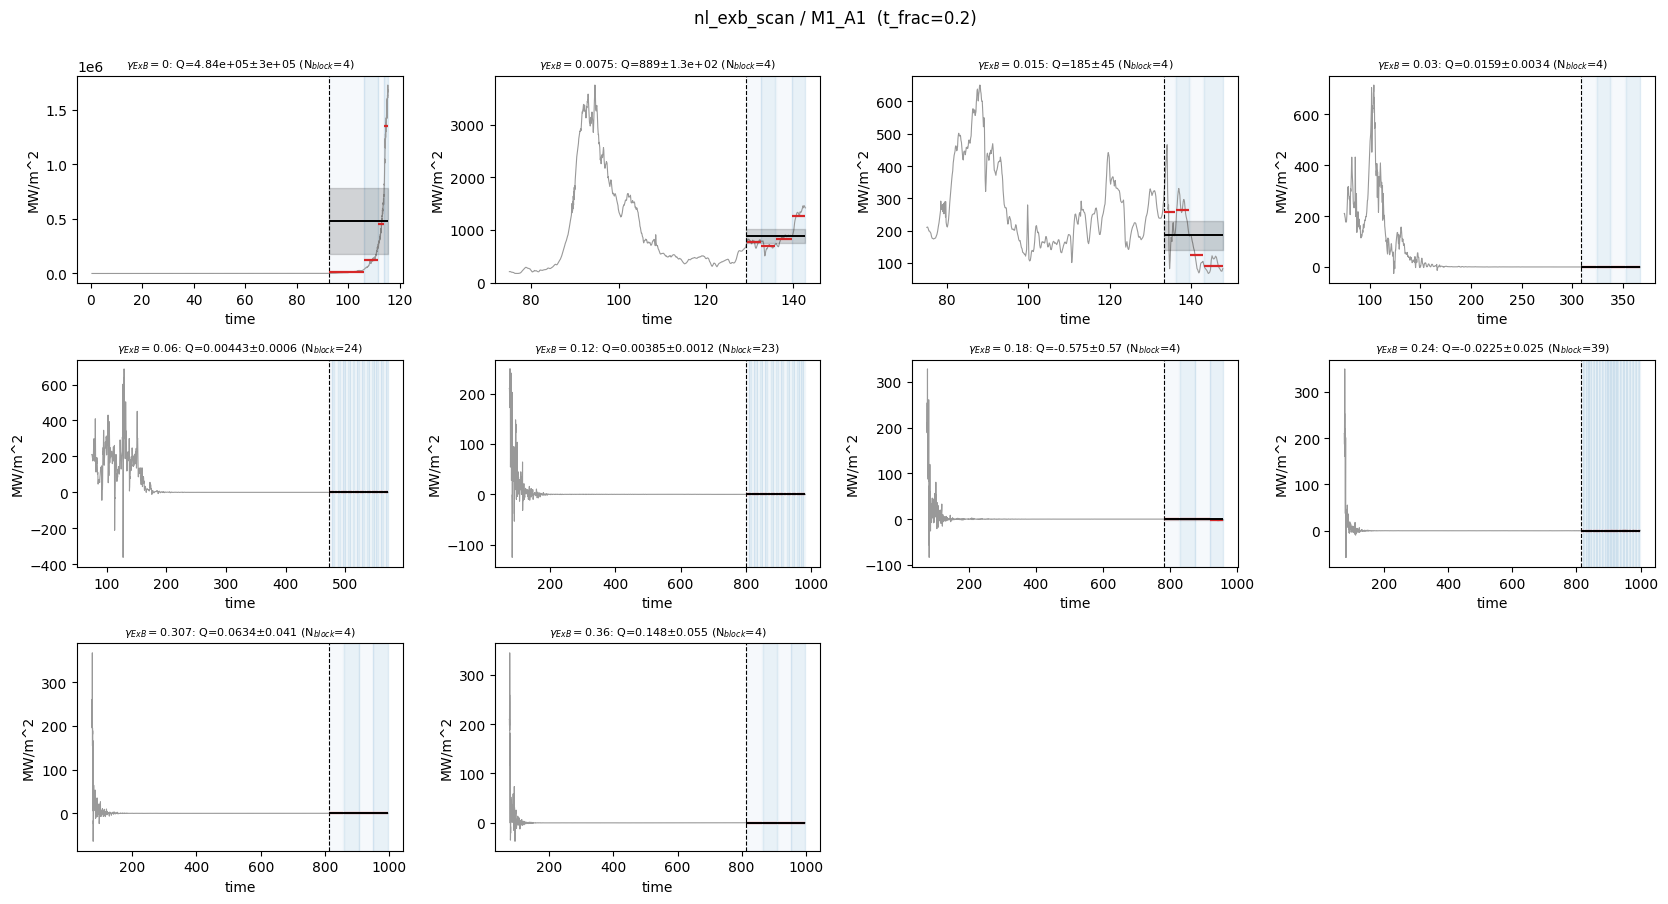

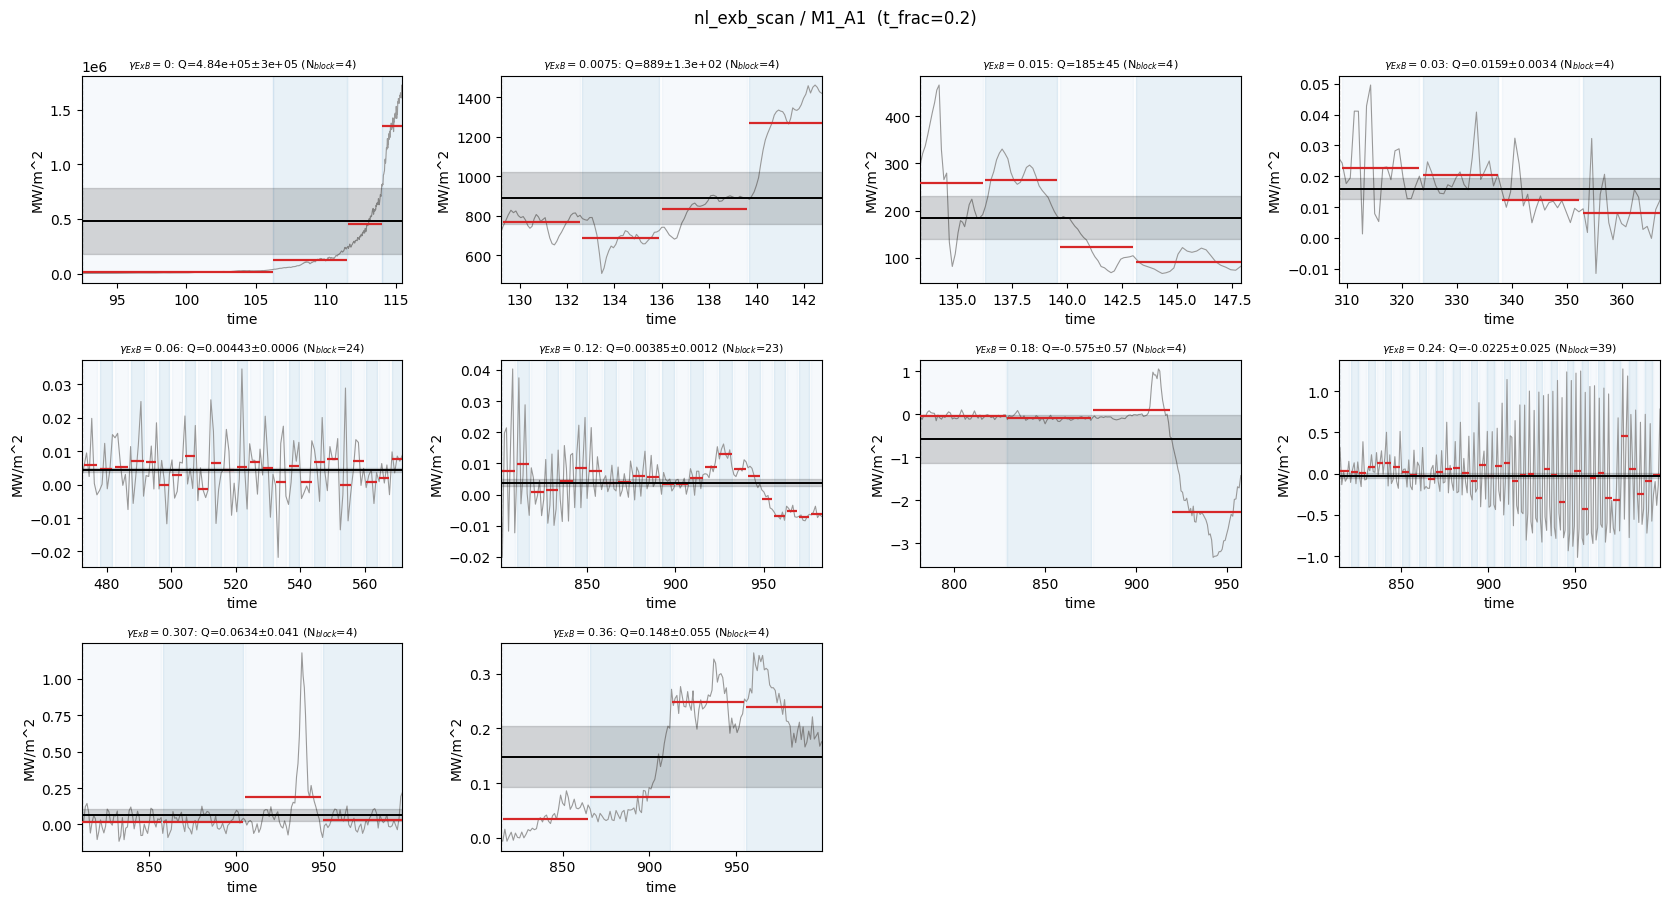

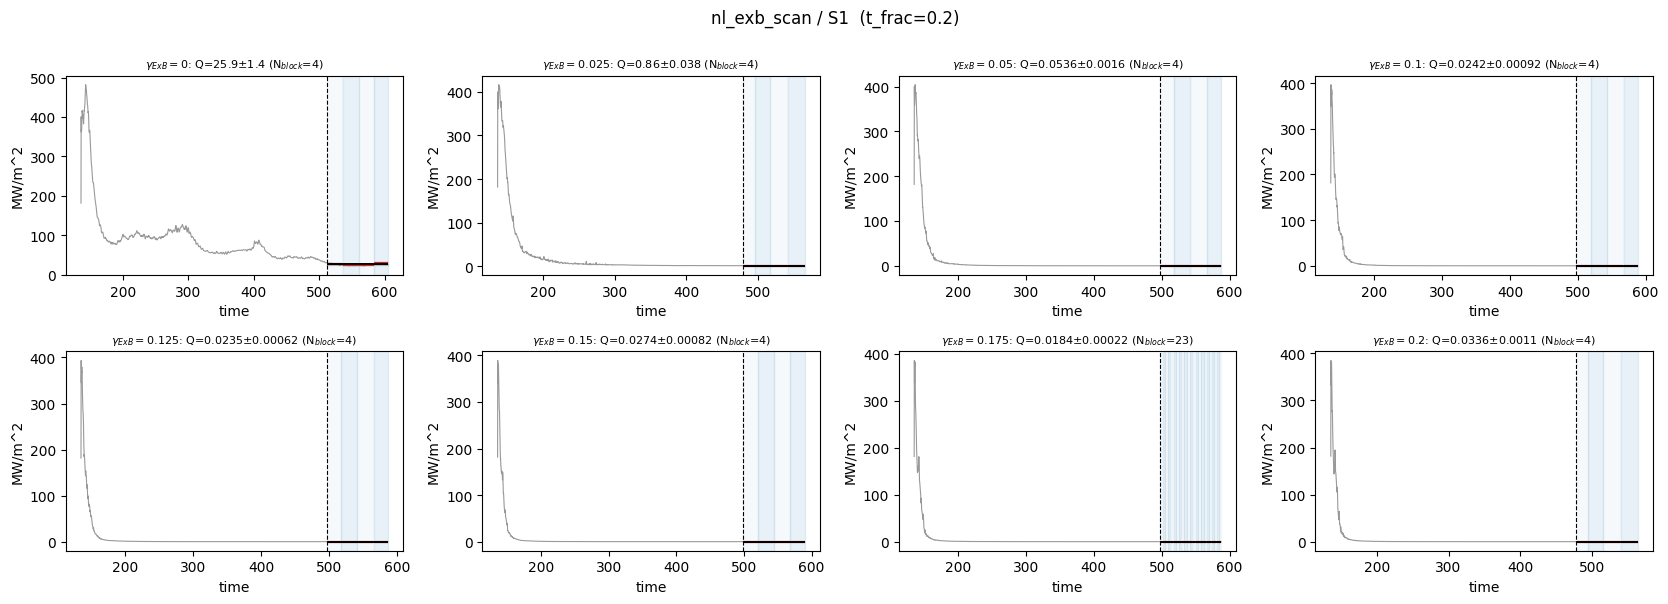

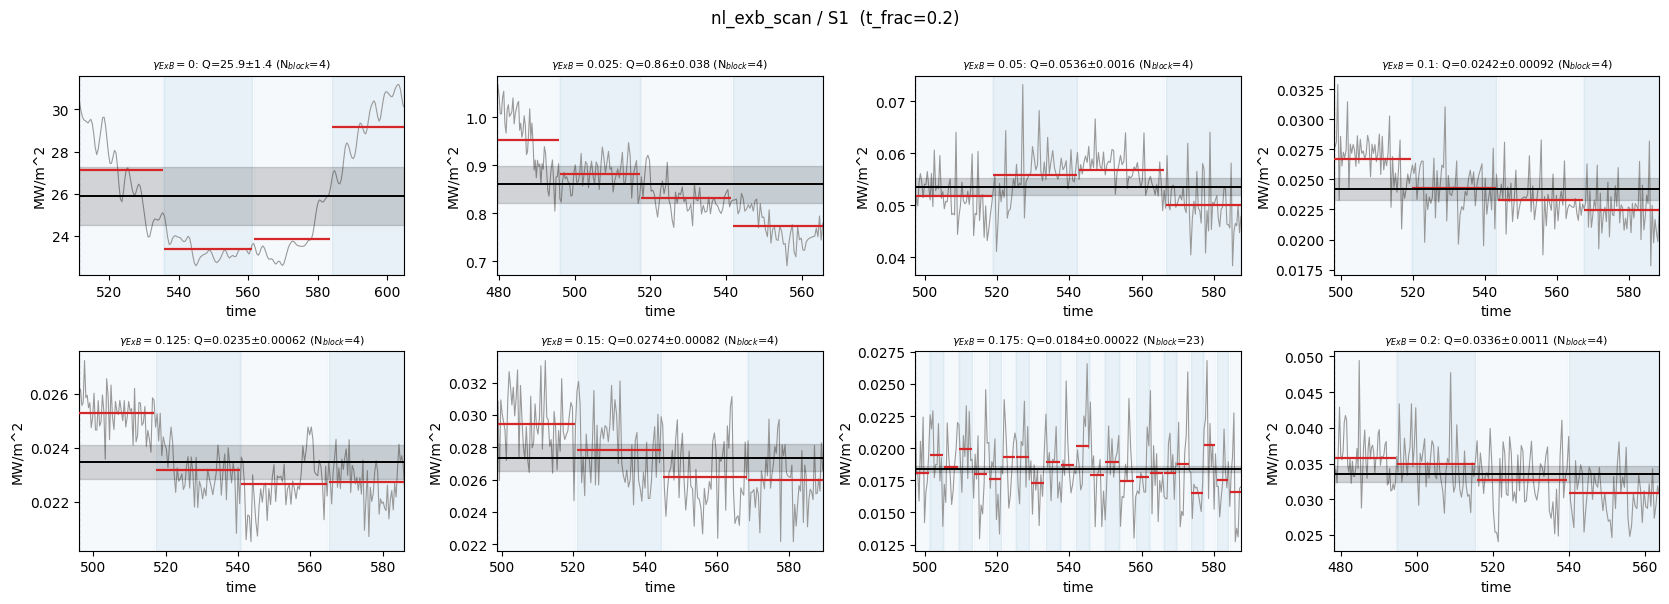

In [ ]:
project = "nl_exb_scan"
for case in project_dict_full[project]:
    plot_convergence(project_dict_full, project, case, t_frac=0.2)              # full trace
    plot_convergence(project_dict_full, project, case, t_frac=0.2, zoom=True)   # window only
plt.show()